In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from optimizers import SVDRiemannianGDSt, QRRiemannianGDSt

torch.manual_seed(42)
device = "cpu"

# 1. EPS-SPECIFIC SETTINGS
plt.rcParams["savefig.format"] = "eps"  # Set default output format
plt.rcParams["ps.useafm"] = True        # Use Adobe Font Metrics (better for EPS)
plt.rcParams["pdf.use14corefonts"] = True  # Compatible core fonts
plt.rcParams["ps.fonttype"] = 42        # Type 42 (TrueType) - best quality
plt.rcParams["pdf.fonttype"] = 42       # For any PDF fallback

# 2. FIGURE SIZE (174mm max width → ~6.85 inches)
width_in = 6                         # 174mm converted to inches
height_in = width_in * 0.52              # 60% of width (adjust ratio as needed)
plt.rcParams["figure.figsize"] = (width_in, height_in)

# 3. FONT CONFIGURATION (No LaTeX)
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"
# Try these font fallbacks in order:
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "Liberation Serif"]

# 4. LINE QUALITY
plt.rcParams["lines.linewidth"] = 1.2   # Slightly thicker for vector output
plt.rcParams["lines.markersize"] = 6    # Visible but not oversized

# 5. FONT SIZES (optimized for print)
plt.rcParams["font.size"] = 10          # Base size
plt.rcParams["axes.labelsize"] = 10     # Axis labels
plt.rcParams["xtick.labelsize"] = 9     # Smaller ticks
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 8     # Compact legend text
plt.rcParams["axes.titlesize"] = 10     # Title size
plt.rcParams["lines.markersize"] = 6           # Default marker size
plt.rcParams["lines.markeredgewidth"] = 1.0    # Marker edge thickness

# 6. SAVING PARAMETERS (Call this when saving)
save_kwargs = {
    "format": "eps",
    "dpi": 300,
    "bbox_inches": "tight",  # Crops whitespace
    "transparent": True  # If you need transparency
}

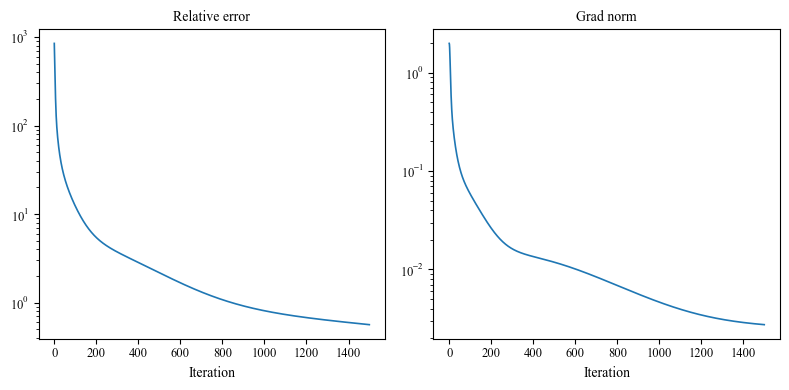

In [39]:
n, p = 100, 2
max_iter = 1500
lr = 1e-1

rel_errors = []
grad_norms = []

def Rayleigh(A, X):
	return 1/X.shape[1] * torch.trace(X.T @ (A @ X))

k = torch.arange(1, n + 1)
eigvals = 2 - 2 * torch.cos(torch.pi * k / (n + 1))

K_n = torch.eye(n, n) * 2.0 + torch.diag(torch.ones(n-1) * -1.0, 1) + torch.diag(torch.ones(n-1) * -1.0, -1)

true_val = torch.mean(eigvals[:p])
X_start = torch.randn(n, p)
U, _, VT = torch.linalg.svd(X_start, full_matrices=False)
X = (U @ VT).requires_grad_(True)

optimizer = SVDRiemannianGDSt([X], lr)

for it in range(max_iter):
    optimizer.zero_grad()
    func = Rayleigh(K_n, X)
    func.backward()
    
    optimizer.step()
    
    grad_norm = optimizer.last_grad_norm
    rel_error = abs(func.item() - true_val) / abs(true_val)
    
    rel_errors.append(rel_error)
    grad_norms.append(grad_norm)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

axes[0].plot(rel_errors, label = 'Relative error')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_title('Relative error') 
axes[1].plot(grad_norms)
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_title('Grad norm')

plt.tight_layout()
plt.show()

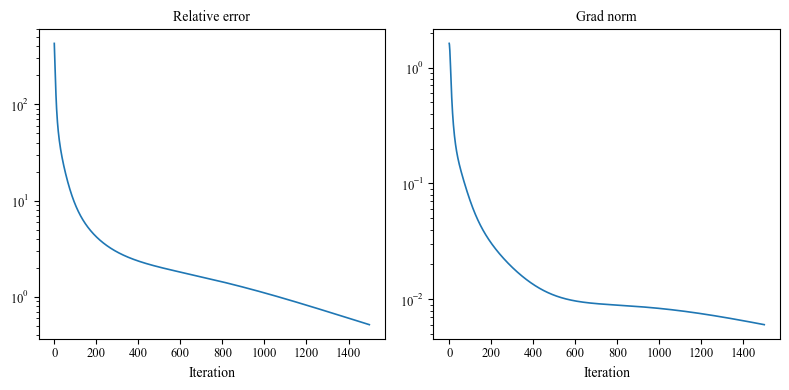

In [38]:
n, p = 100, 3
max_iter = 1500
lr = 1e-1

rel_errors = []
grad_norms = []

def Rayleigh(A, X):
	return 1/X.shape[1] * torch.trace(X.T @ (A @ X))

k = torch.arange(1, n + 1)
eigvals = 2 - 2 * torch.cos(torch.pi * k / (n + 1))

K_n = torch.eye(n, n) * 2.0 + torch.diag(torch.ones(n-1) * -1.0, 1) + torch.diag(torch.ones(n-1) * -1.0, -1)

true_val = torch.mean(eigvals[:p])
X_start = torch.randn(n, p)
U, _, VT = torch.linalg.svd(X_start, full_matrices=False)
X = (U @ VT).requires_grad_(True)

optimizer = SVDRiemannianGDSt([X], lr)

for it in range(max_iter):
    optimizer.zero_grad()
    func = Rayleigh(K_n, X)
    func.backward()
    
    optimizer.step()
    
    grad_norm = optimizer.last_grad_norm
    rel_error = abs(func.item() - true_val) / abs(true_val)
    
    rel_errors.append(rel_error)
    grad_norms.append(grad_norm)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

axes[0].plot(rel_errors, label = 'Relative error')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_title('Relative error') 
axes[1].plot(grad_norms)
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_title('Grad norm')

plt.tight_layout()
plt.show()

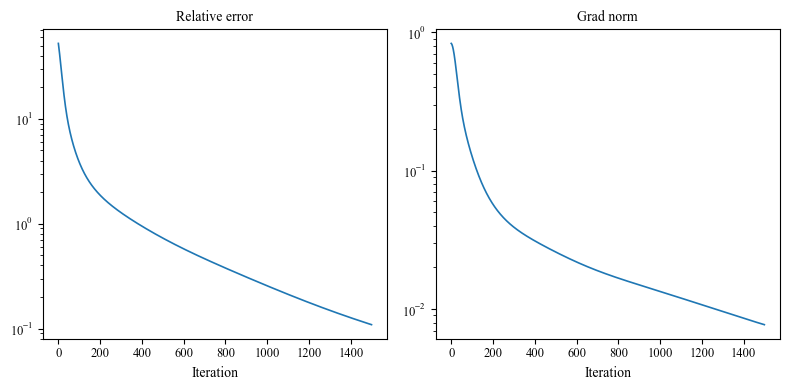

In [40]:
n, p = 100, 10
max_iter = 1500
lr = 1e-1

rel_errors = []
grad_norms = []

def Rayleigh(A, X):
	return 1/X.shape[1] * torch.trace(X.T @ (A @ X))

k = torch.arange(1, n + 1)
eigvals = 2 - 2 * torch.cos(torch.pi * k / (n + 1))

K_n = torch.eye(n, n) * 2.0 + torch.diag(torch.ones(n-1) * -1.0, 1) + torch.diag(torch.ones(n-1) * -1.0, -1)

true_val = torch.mean(eigvals[:p])
X_start = torch.randn(n, p)
U, _, VT = torch.linalg.svd(X_start, full_matrices=False)
X = (U @ VT).requires_grad_(True)

optimizer = SVDRiemannianGDSt([X], lr)

for it in range(max_iter):
    optimizer.zero_grad()
    func = Rayleigh(K_n, X)
    func.backward()
    
    optimizer.step()
    
    grad_norm = optimizer.last_grad_norm
    rel_error = abs(func.item() - true_val) / abs(true_val)
    
    rel_errors.append(rel_error)
    grad_norms.append(grad_norm)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

axes[0].plot(rel_errors, label = 'Relative error')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_title('Relative error') 
axes[1].plot(grad_norms)
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_title('Grad norm')

plt.tight_layout()
plt.show()

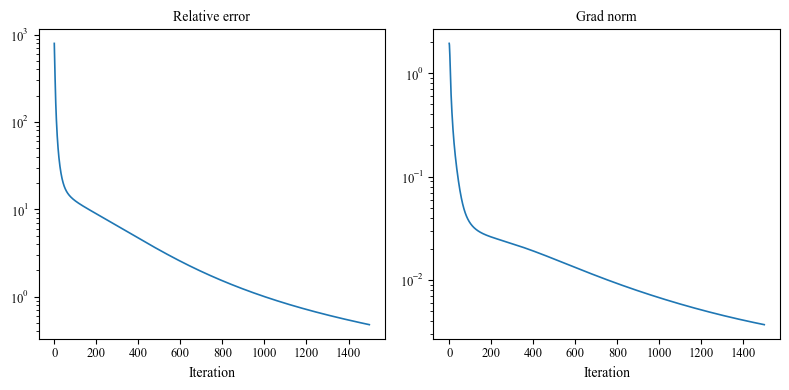

In [42]:
n, p = 100, 2
max_iter = 1500
lr = 1e-1

rel_errors = []
grad_norms = []

def Rayleigh(A, X):
	return 1/X.shape[1] * torch.trace(X.T @ (A @ X))

k = torch.arange(1, n + 1)
eigvals = 2 - 2 * torch.cos(torch.pi * k / (n + 1))

K_n = torch.eye(n, n) * 2.0 + torch.diag(torch.ones(n-1) * -1.0, 1) + torch.diag(torch.ones(n-1) * -1.0, -1)

true_val = torch.mean(eigvals[:p])
X_start = torch.randn(n, p)
Q, _ = torch.linalg.qr(X_start)
X = Q.requires_grad_(True)

optimizer = QRRiemannianGDSt([X], lr)

for it in range(max_iter):
    optimizer.zero_grad()
    func = Rayleigh(K_n, X)
    func.backward()
    
    optimizer.step()
    
    grad_norm = optimizer.last_grad_norm
    rel_error = abs(func.item() - true_val) / abs(true_val)
    
    rel_errors.append(rel_error)
    grad_norms.append(grad_norm)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

axes[0].plot(rel_errors, label = 'Relative error')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_title('Relative error') 
axes[1].plot(grad_norms)
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_title('Grad norm')

plt.tight_layout()
plt.show()

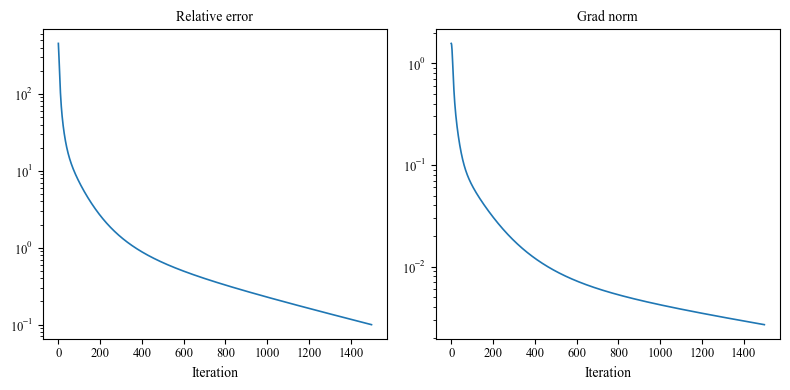

In [43]:
n, p = 100, 3
max_iter = 1500
lr = 1e-1

rel_errors = []
grad_norms = []

def Rayleigh(A, X):
	return 1/X.shape[1] * torch.trace(X.T @ (A @ X))

k = torch.arange(1, n + 1)
eigvals = 2 - 2 * torch.cos(torch.pi * k / (n + 1))

K_n = torch.eye(n, n) * 2.0 + torch.diag(torch.ones(n-1) * -1.0, 1) + torch.diag(torch.ones(n-1) * -1.0, -1)

true_val = torch.mean(eigvals[:p])
X_start = torch.randn(n, p)
Q, _ = torch.linalg.qr(X_start)
X = Q.requires_grad_(True)

optimizer = QRRiemannianGDSt([X], lr)

for it in range(max_iter):
    optimizer.zero_grad()
    func = Rayleigh(K_n, X)
    func.backward()
    
    optimizer.step()
    
    grad_norm = optimizer.last_grad_norm
    rel_error = abs(func.item() - true_val) / abs(true_val)
    
    rel_errors.append(rel_error)
    grad_norms.append(grad_norm)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

axes[0].plot(rel_errors, label = 'Relative error')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_title('Relative error') 
axes[1].plot(grad_norms)
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_title('Grad norm')

plt.tight_layout()
plt.show()

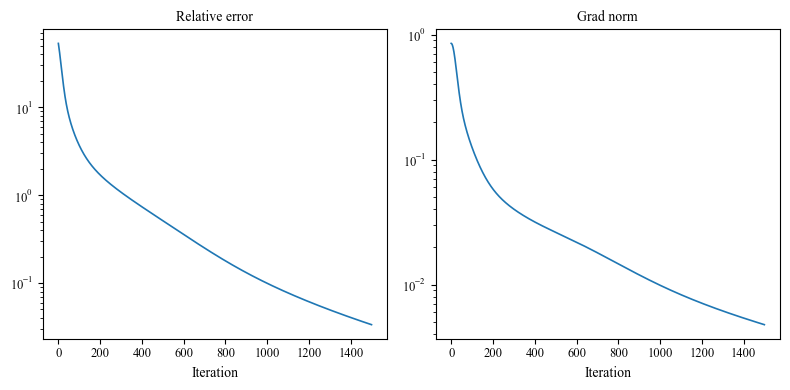

In [44]:
n, p = 100, 10
max_iter = 1500
lr = 1e-1

rel_errors = []
grad_norms = []

def Rayleigh(A, X):
	return 1/X.shape[1] * torch.trace(X.T @ (A @ X))

k = torch.arange(1, n + 1)
eigvals = 2 - 2 * torch.cos(torch.pi * k / (n + 1))

K_n = torch.eye(n, n) * 2.0 + torch.diag(torch.ones(n-1) * -1.0, 1) + torch.diag(torch.ones(n-1) * -1.0, -1)

true_val = torch.mean(eigvals[:p])
X_start = torch.randn(n, p)
Q, _ = torch.linalg.qr(X_start)
X = Q.requires_grad_(True)

optimizer = QRRiemannianGDSt([X], lr)

for it in range(max_iter):
    optimizer.zero_grad()
    func = Rayleigh(K_n, X)
    func.backward()
    
    optimizer.step()
    
    grad_norm = optimizer.last_grad_norm
    rel_error = abs(func.item() - true_val) / abs(true_val)
    
    rel_errors.append(rel_error)
    grad_norms.append(grad_norm)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

axes[0].plot(rel_errors, label = 'Relative error')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_title('Relative error') 
axes[1].plot(grad_norms)
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_title('Grad norm')

plt.tight_layout()
plt.show()